# One-dimensional linear OT PCA

This notebook generates `fig:linear-ot-1d-pca`.  In one dimension, the quadratic Wasserstein geometry is exactly linearized by quantile functions: a probability density \(\alpha\) is represented by

$$
    Q_\alpha(u) = F_\alpha^{-1}(u), \qquad u\in(0,1),
$$

and \(\mathcal W_2^2(\alpha,\beta)=\int_0^1 |Q_\alpha(u)-Q_\beta(u)|^2\,du\).  We build a large synthetic dataset of two-Gaussian mixtures with varying locations and scales, compute PCA in the Hilbert space \(L^2(0,1)\), and convert excursions along the leading quantile directions back into densities for display.  Only a small representative subset of the dataset is shown in the figure; the principal components are estimated from the full ensemble.


In [1]:
from pathlib import Path
import os
import sys
import shutil

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        FIGROOT = candidate.resolve()
        ROOT = FIGROOT.parent
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

from figure_style import BLUE, GRAY, RED, VIOLET, box_axes, figure_dir, interp_color, save_pdf, setup_matplotlib

setup_matplotlib()

NAME = "linear-ot-1d-pca"
OUT = figure_dir(NAME)
THUMB = FIGROOT / "thumbnails" / f"{NAME}.png"
THUMB.parent.mkdir(parents=True, exist_ok=True)
ARXIV_OUT = ROOT / "arxiv" / "figures"
ARXIV_OUT.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(203911)


## Synthetic two-Gaussian mixtures

Each training measure is a mixture of two well-separated Gaussian bumps.  A few low-dimensional latent variables induce moderate global translation, component-wise translations, and component-wise scale changes without collapsing the valley between the modes.  The PCA is fit on a much larger hidden training ensemble than the curves shown in the panel, so the displayed densities should be read as representatives rather than as the full sample.  The PCA itself is performed on finely sampled quantile functions.


In [3]:
def gaussian_pdf(x, mean, sigma):
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2) / (np.sqrt(2 * np.pi) * sigma)


def normalize_density(x, rho):
    rho = np.maximum(rho, 0.0)
    mass = np.trapezoid(rho, x)
    return rho / max(mass, 1e-15)


def quantile_from_density(x, rho, u):
    dx = np.diff(x)
    cdf = np.empty_like(x)
    cdf[0] = 0.0
    cdf[1:] = np.cumsum(0.5 * (rho[:-1] + rho[1:]) * dx)
    cdf = cdf / max(cdf[-1], 1e-15)
    cdf = np.maximum.accumulate(cdf)
    cdf[-1] = 1.0
    return np.interp(u, cdf, x)


def density_from_quantile(q, u, x, *, smooth=34.0):
    # Since q=F^{-1}, the density at q(u) is 1/q'(u).
    # The quantile is smoothed before differentiation only for display, to
    # avoid amplifying interpolation noise in very low-density valleys.
    q = np.maximum.accumulate(q)
    q_smooth = gaussian_filter1d(q, sigma=24.0, mode="nearest")
    q_smooth = np.maximum.accumulate(q_smooth)
    dq = np.gradient(q_smooth, u)
    dq = gaussian_filter1d(dq, sigma=34.0, mode="nearest")
    dq = np.maximum(dq, 2e-4)
    values = 1.0 / dq
    order = np.argsort(q_smooth)
    rho = np.interp(x, q_smooth[order], values[order], left=0.0, right=0.0)
    rho = gaussian_filter1d(rho, sigma=smooth, mode="nearest")
    return normalize_density(x, rho)


x = np.linspace(-4.2, 4.2, 5200)
u = np.linspace(3e-5, 1 - 3e-5, 7200)
N_TRAIN = 900
N_DISPLAY = 12
N = N_TRAIN
latent = rng.normal(size=(N_TRAIN, 5))

# Keep the two modes well separated.  The latent variables only induce
# moderate component-wise translations and scale changes, so the PCA modes are
# readable as deformations of two persistent bumps rather than mode merging.
base_left, base_right = -1.48, 1.48
global_shift = 0.12 * latent[:, 0]
left_shift = 0.20 * np.tanh(latent[:, 1])
right_shift = 0.20 * np.tanh(0.75 * latent[:, 2])
scale_latent = latent[:, 3]
weight_skew = 0.06 * np.tanh(latent[:, 4])

means_left = base_left + global_shift + left_shift + 0.035 * rng.normal(size=N)
means_right = base_right + global_shift + right_shift + 0.035 * rng.normal(size=N)
sigmas_left = 0.185 * np.exp(0.16 * scale_latent + 0.035 * rng.normal(size=N))
sigmas_right = 0.225 * np.exp(-0.14 * scale_latent + 0.035 * rng.normal(size=N))
weights_left = np.clip(0.50 + weight_skew, 0.40, 0.60)

params = []
densities = []
quantiles = []
for wl, ml, mr, sl, sr in zip(weights_left, means_left, means_right, sigmas_left, sigmas_right):
    rho = wl * gaussian_pdf(x, ml, sl) + (1 - wl) * gaussian_pdf(x, mr, sr)
    rho = normalize_density(x, rho)
    densities.append(rho)
    quantiles.append(quantile_from_density(x, rho, u))
    params.append((wl, ml, mr, sl, sr))

densities = np.asarray(densities)
quantiles = np.asarray(quantiles)
print(f"PCA training ensemble: {N_TRAIN} two-Gaussian mixtures")
print(f"displayed representative curves: {N_DISPLAY}")
print(f"quantile grid: {len(u)} points, density grid: {len(x)} points")


PCA training ensemble: 900 two-Gaussian mixtures
displayed representative curves: 12
quantile grid: 7200 points, density grid: 5200 points


## PCA in quantile coordinates

The quadrature weights approximate the \(L^2(0,1)\) inner product.  If \(\bar Q\) is the empirical mean quantile and \(e_k\) is a unit principal direction, the displayed excursions are

$$
    Q_{k,a}(u)=\bar Q(u)+a e_k(u), \qquad a\in[-A_k,A_k].
$$

The amplitudes \(A_k\) are chosen large enough to show visible deformations and small enough to keep the quantile functions increasing. For display, the densities are reconstructed from the relation \(\rho(Q(u))=1/Q'(u)\), with a mild smoothing of the quantile derivative to suppress numerical artifacts in very low-density valleys.


In [5]:
du = np.empty_like(u)
du[1:-1] = 0.5 * (u[2:] - u[:-2])
du[0] = u[1] - u[0]
du[-1] = u[-1] - u[-2]
du = du / du.sum()

Qbar = quantiles.mean(axis=0)
X = (quantiles - Qbar) * np.sqrt(du)[None, :]

# The training ensemble is intentionally much larger than the displayed subset.
# Computing the PCA from the sample Gram matrix avoids a full SVD of the dense
# N_TRAIN x len(u) quantile matrix while giving the same leading directions.
G = X @ X.T
evals, U = np.linalg.eigh(G)
order = np.argsort(evals)[::-1]
evals = np.maximum(evals[order], 0.0)
U = U[:, order]
singular = np.sqrt(evals)
explained = evals / (N_TRAIN - 1)

n_components = 5
Vt = (U[:, :n_components].T @ X) / np.maximum(singular[:n_components, None], 1e-15)
modes = Vt[:3] / np.sqrt(du)[None, :]

# Fix the arbitrary PCA signs so reruns keep the same red-to-blue orientation.
for k in range(3):
    imax = int(np.argmax(np.abs(modes[k])))
    if modes[k, imax] < 0:
        modes[k] *= -1
        Vt[k] *= -1
mode_std = np.sqrt(explained[:3])


# For the figure, use display amplitudes from the empirical range of the
# projected scores, then extrapolate slightly.  The density reconstruction below
# monotone-rearranges the resulting quantiles, so tiny tail non-monotonicities do
# not dominate the visual amplitude of the informative central mass.
scores = X @ Vt[:3].T
score_span = np.quantile(np.abs(scores[:, :3]), 0.96, axis=0)
amplitudes = np.array([1.35, 1.75, 1.75]) * score_span
mean_density = density_from_quantile(Qbar, u, x, smooth=1.05)
print("explained variance ratio:", np.round(explained[:5] / explained.sum(), 3))
print("score 96% spans:", np.round(score_span, 3))
print("display amplitudes:", np.round(amplitudes, 3))


explained variance ratio: [0.594 0.124 0.103 0.046 0.042]
score 96% spans: [0.473 0.281 0.222]
display amplitudes: [0.639 0.492 0.388]


## Rendering panels

The dataset panel shows only representative training densities and their Wasserstein barycenter, obtained by averaging all training quantiles.  Each mode panel overlays density snapshots along a single quantile-PCA direction, with red-to-blue colors encoding increasing coefficient \(a\).


In [7]:
def finish_density_axis(ax, ymax=None):
    ax.set_xlim(-3.75, 3.75)
    if ymax is not None:
        ax.set_ylim(0, ymax)
    ax.tick_params(labelbottom=False, labelleft=False)
    box_axes(ax)


def plot_density_curve(ax, rho, color, *, lw=1.0, alpha=1.0, fill=False, zorder=2):
    if fill:
        ax.fill_between(x, 0, rho, color=color, alpha=0.075 * alpha, linewidth=0, zorder=zorder - 1)
    ax.plot(x, rho, color=color, lw=lw, alpha=alpha, zorder=zorder)


# Pick examples spanning the first two PCA scores, not merely random curves.
scores = X @ Vt[:3].T
angles = np.arctan2(scores[:, 1], scores[:, 0])
chosen = []
for theta in np.linspace(-np.pi, np.pi, N_DISPLAY, endpoint=False):
    score = np.cos(angles - theta) * np.linalg.norm(scores[:, :2], axis=1)
    idx = int(np.argmax(score))
    if idx not in chosen:
        chosen.append(idx)
while len(chosen) < N_DISPLAY:
    idx = int(rng.integers(0, N_TRAIN))
    if idx not in chosen:
        chosen.append(idx)

# Dataset examples.
fig, ax = plt.subplots(figsize=(3.15, 1.72))
for j, idx in enumerate(chosen):
    color = interp_color(j / max(len(chosen) - 1, 1))
    plot_density_curve(ax, densities[idx], color, lw=0.82, alpha=0.60, fill=False, zorder=2)
plot_density_curve(ax, mean_density, VIOLET, lw=1.35, alpha=0.96, fill=False, zorder=5)
finish_density_axis(ax, ymax=2.65)
save_pdf(fig, OUT / "dataset.pdf", pad_inches=0.045)
plt.close(fig)

mode_densities = []
for k in range(3):
    coeffs = np.linspace(-amplitudes[k], amplitudes[k], 8)
    panel = []
    for a in coeffs:
        q = Qbar + a * modes[k]
        panel.append(density_from_quantile(q, u, x))
    mode_densities.append(np.asarray(panel))
    fig, ax = plt.subplots(figsize=(3.15, 1.72))
    for j, rho in enumerate(panel):
        color = interp_color(j / (len(panel) - 1))
        plot_density_curve(ax, rho, color, lw=1.00, alpha=0.92, fill=True, zorder=2 + j)
    finish_density_axis(ax, ymax=max(2.75, 1.08 * np.max(panel)))
    save_pdf(fig, OUT / f"mode-{k+1}.pdf", pad_inches=0.045)
    plt.close(fig)


In [8]:
# Thumbnail/contact sheet for the notebook gallery.
fig, axes = plt.subplots(2, 2, figsize=(6.6, 3.55))
axes = axes.ravel()
for j, idx in enumerate(chosen[:10]):
    axes[0].plot(x, densities[idx], color=interp_color(j / 9), lw=0.78, alpha=0.58)
axes[0].plot(x, mean_density, color=VIOLET, lw=1.28)
for k in range(3):
    ax = axes[k + 1]
    panel = mode_densities[k]
    for j, rho in enumerate(panel):
        ax.fill_between(x, 0, rho, color=interp_color(j / (len(panel) - 1)), alpha=0.055, linewidth=0)
        ax.plot(x, rho, color=interp_color(j / (len(panel) - 1)), lw=0.92, alpha=0.92)
for ax in axes:
    finish_density_axis(ax, ymax=None)
fig.subplots_adjust(wspace=0.12, hspace=0.22)
fig.savefig(THUMB, dpi=170, bbox_inches="tight", pad_inches=0.05)
plt.close(fig)

for pdf in OUT.glob("*.pdf"):
    shutil.copy2(pdf, ARXIV_OUT / f"{NAME}--{pdf.name}")

print(f"wrote {OUT}")
print(f"thumbnail: {THUMB}")


wrote /Users/gpeyre/Dropbox/github/ot4ml/OT4ML/figures/linear-ot-1d-pca
thumbnail: /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/linear-ot-1d-pca.png


## Visual check

The notebook exports separate PDF panels for LaTeX and a compact PNG thumbnail for the searchable gallery.


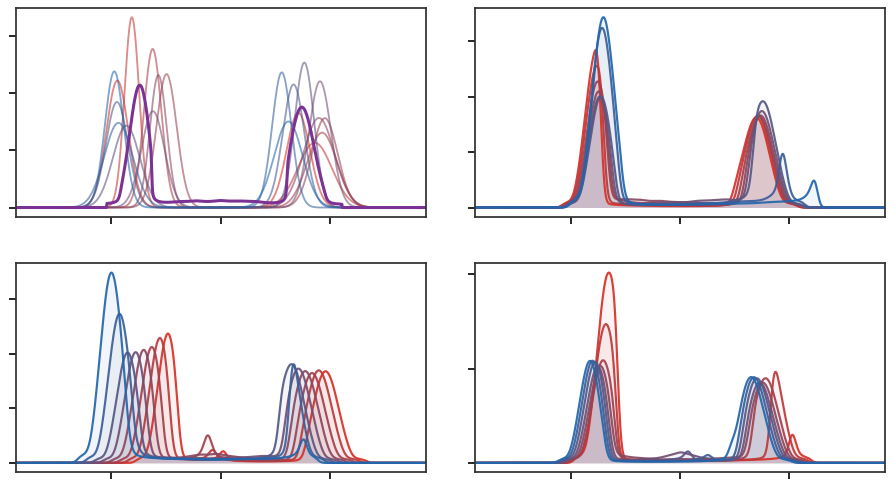

In [10]:
from IPython.display import Image, display

display(Image(filename=str(THUMB)))
